## import libraries

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


## import DataSet

In [26]:
df=pd.read_csv("data/transit_ridership.csv")

## Checking Columns of Data Set


In [8]:
pd.DataFrame(df.columns, columns=['Column Name'])


,Column Name
0,date
1,route_id
2,direction
3,boarding_count
4,alighting_count
5,vehicle_type
6,trip_duration_min
7,weather
8,temperature_c
9,is_holiday


In [9]:
# Checking first five Rows of Dataset
df.head()

,date,route_id,direction,boarding_count,alighting_count,vehicle_type,trip_duration_min,weather,temperature_c,is_holiday
0,2024-10-21,R205,Inbound,388.0,57.0,Minibus,77.9,Clear,-14.3,false
1,2024-08-29,R105,Outbound,457.0,169.0,Articulated Bus,76.6,Snow,-1.1,false
2,2024-08-31,R207,Inbound,NaN,518.0,Articulated Bus,58.5,Overcast,22.8,False
3,2024-12-24,R208,Outbound,354.0,302.0,Articulated Bus,47.4,Snow,29.6,0
4,2024-03-05,R207,Inbound,423.0,643.0,Minibus,17.4,Overcast,-11.7,No


In [10]:
# Checking last five Rows of Dataset
df.tail()


,date,route_id,direction,boarding_count,alighting_count,vehicle_type,trip_duration_min,weather,temperature_c,is_holiday
1988,2024-07-07,R104,Inbound,216.0,599.0,Articulated Bus,82.2,Snow,29.7,0
1989,2024-06-11,R104,Outbound,41.0,464.0,Minibus,76.9,Snow,21.0,0
1990,2024-09-29,R205,Outbound,103.0,413.0,Minibus,55.8,Rain,-3.3,False
1991,2024-10-21,R206,Inbound,139.0,623.0,Articulated Bus,21.7,Overcast,36.9,false
1992,2024-11-12,R302,Outbound,745.0,677.0,Minibus,NaN,Rain,8.4,false


 ## Describing the dataset

In [12]:
df.describe()

,boarding_count,alighting_count,trip_duration_min,temperature_c
count,1854.000000,1907.000000,1883.000000,1940.000000
mean,410.625674,381.549554,56.235582,14.030052
std,222.595905,214.463238,58.949897,16.434646
min,20.000000,15.000000,-12.300000,-15.000000
25%,216.250000,191.500000,32.900000,-0.300000
50%,412.500000,379.000000,52.500000,14.200000
75%,600.000000,565.500000,71.400000,28.500000
max,800.000000,750.000000,999.000000,42.000000


## Checking info about dataset

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1993 non-null   str    
 1   route_id           1993 non-null   str    
 2   direction          1993 non-null   str    
 3   boarding_count     1854 non-null   float64
 4   alighting_count    1907 non-null   float64
 5   vehicle_type       1993 non-null   str    
 6   trip_duration_min  1883 non-null   float64
 7   weather            1993 non-null   str    
 8   temperature_c      1940 non-null   float64
 9   is_holiday         1993 non-null   str    
dtypes: float64(4), str(6)
memory usage: 155.8 KB


## Checking shape of data set

In [14]:
df.shape

(1993, 10)

## Checking if there is any Null values in dataset

In [15]:
df.isnull().sum()

date                   0
route_id               0
direction              0
boarding_count       139
alighting_count       86
vehicle_type           0
trip_duration_min    110
weather                0
temperature_c         53
is_holiday             0
dtype: int64

## Converting date column to datetime

In [21]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"].dtype

dtype('<M8[us]')

## Checking duplicate rows in the dataset

In [34]:
df.duplicated().sum()

np.int64(30)

In [35]:
df = df.drop_duplicates()

In [36]:
df.shape

(1963, 10)

## Checking unique values in direction

In [37]:
df["direction"].unique()

<StringArray>
[ 'Inbound', 'Outbound', 'OUTBOUND',      'Out',  'INBOUND',       'In',
  'inbound',   'Outbnd', 'outbound',    'Inbnd']
Length: 10, dtype: str

In [38]:
df["direction"] = df["direction"].replace({
    "INBOUND": "Inbound",
    "In": "Inbound",
    "inbound": "Inbound",
    "Inbnd": "Inbound",
    "OUTBOUND": "Outbound",
    "Out": "Outbound",
    "outbound": "Outbound",
    "Outbnd": "Outbound"
})

In [39]:
df["direction"].unique()

<StringArray>
['Inbound', 'Outbound']
Length: 2, dtype: str

## Checking unique values in is_holiday

In [47]:

df["is_holiday"].value_counts()

is_holiday
False    1905
True       58
Name: count, dtype: int64

In [41]:
df["is_holiday"] = df["is_holiday"].replace({
    "false": "False",
    "False": "False",
    "0": "False",
    "No": "False",
    "true": "True",
    "True": "True",
    "1": "True",
    "Yes": "True"
})

In [42]:
df["is_holiday"].unique()

<StringArray>
['False', 'True']
Length: 2, dtype: str

## Checking unique values in vehicle_type

In [43]:
df["vehicle_type"].unique()

<StringArray>
[        'Minibus', 'Articulated Bus',    'Standard Bus',        'mini bus',
         'MINIBUS',         'std bus',    'standard bus',         'Std Bus',
     'articulated']
Length: 9, dtype: str

In [44]:
df["vehicle_type"] = df["vehicle_type"].replace({
    "mini bus": "Minibus",
    "MINIBUS": "Minibus",
    "std bus": "Standard Bus",
    "standard bus": "Standard Bus",
    "Std Bus": "Standard Bus",
    "articulated": "Articulated Bus"
})

In [46]:
df["vehicle_type"].value_counts()

vehicle_type
Standard Bus       671
Minibus            659
Articulated Bus    633
Name: count, dtype: int64

## Observation
The vehicle_type column contained multiple inconsistent labels for the same categories. These values were standardized into `Minibus`, `Standard Bus`, and `Articulated Bus`.

## Checking missing values in the dataset

In [48]:
df.isnull().sum()

date                   0
route_id               0
direction              0
boarding_count       137
alighting_count       85
vehicle_type           0
trip_duration_min    110
weather                0
temperature_c         52
is_holiday             0
dtype: int64

In [49]:
df["boarding_count"] = df["boarding_count"].fillna(df["boarding_count"].median())
df["alighting_count"] = df["alighting_count"].fillna(df["alighting_count"].median())
df["trip_duration_min"] = df["trip_duration_min"].fillna(df["trip_duration_min"].median())
df["temperature_c"] = df["temperature_c"].fillna(df["temperature_c"].median())

In [50]:
df.isnull().sum()

date                 0
route_id             0
direction            0
boarding_count       0
alighting_count      0
vehicle_type         0
trip_duration_min    0
weather              0
temperature_c        0
is_holiday           0
dtype: int64

## Observation
Missing values in numerical columns were filled using the median. This method is useful because it is less affected by extreme values.

## Checking negative values in `trip_duration_min`

In [59]:
df[df["trip_duration_min"] < 0]

,date,route_id,direction,boarding_count,alighting_count,vehicle_type,trip_duration_min,weather,temperature_c,is_holiday


In [54]:
(df["trip_duration_min"] < 0).sum()

np.int64(16)

In [55]:
df.loc[df["trip_duration_min"] < 0, "trip_duration_min"] = df["trip_duration_min"].median()

## Observation
Negative values were found in `trip_duration_min`, which are not valid for trip duration. These values were replaced with the median of the column.

## Monthly Ridership (Total Boardings)

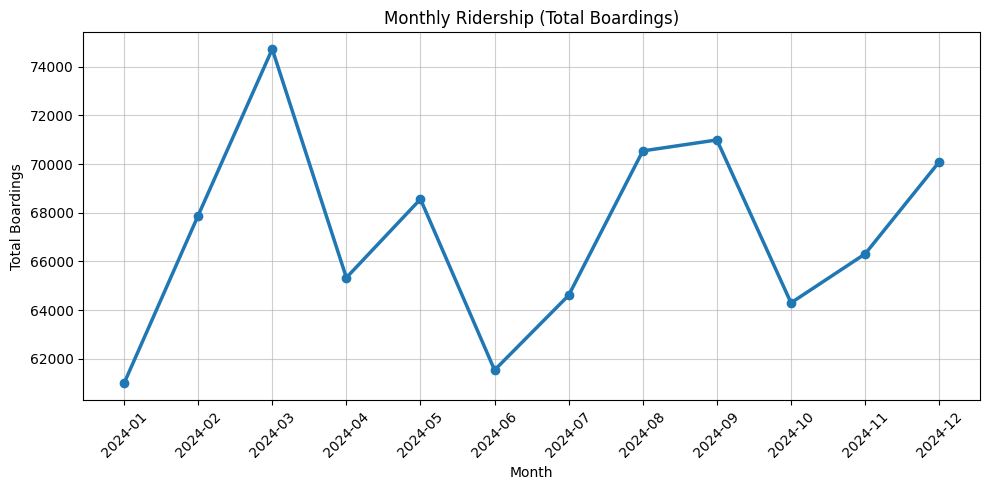

In [110]:
os.makedirs("expected_output", exist_ok=True)

monthly_ridership = df.groupby(df["date"].dt.to_period("M"))["boarding_count"].sum()
monthly_ridership.index = monthly_ridership.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_ridership.index, monthly_ridership.values, marker="o", linewidth=2.5)
plt.title("Monthly Ridership (Total Boardings)")
plt.xlabel("Month")
plt.ylabel("Total Boardings")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.savefig("expected_output/monthly_ridership.png")
plt.show()

## Total Boardings by Route

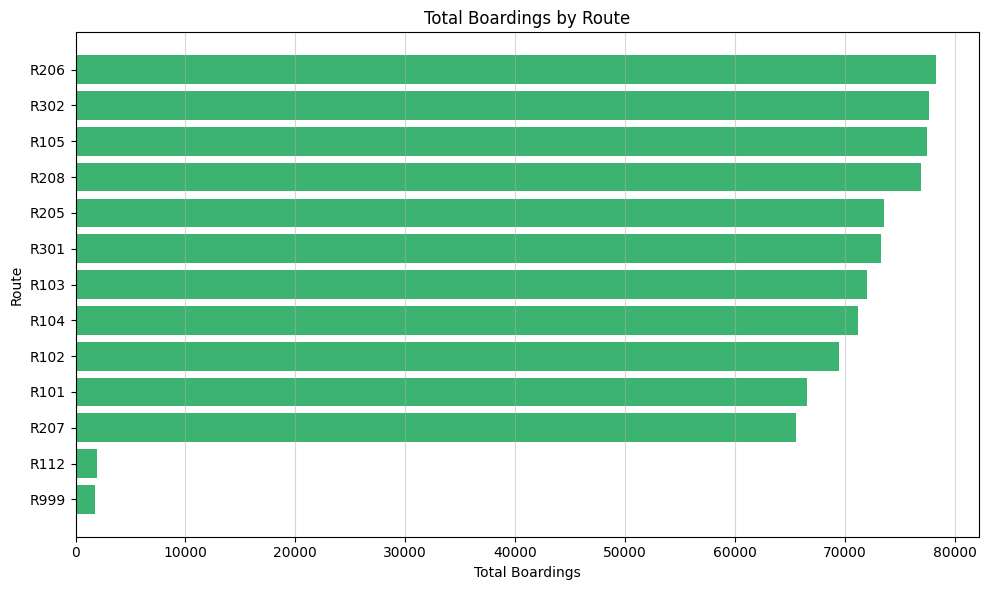

In [112]:
route_ridership = df.groupby("route_id")["boarding_count"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(route_ridership.index, route_ridership.values, color="mediumseagreen")
plt.title("Total Boardings by Route")
plt.xlabel("Total Boardings")
plt.ylabel("Route")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.savefig("expected_output/ridership_by_route.png")
plt.show()

## Average Trip Duration by Vehicle Type

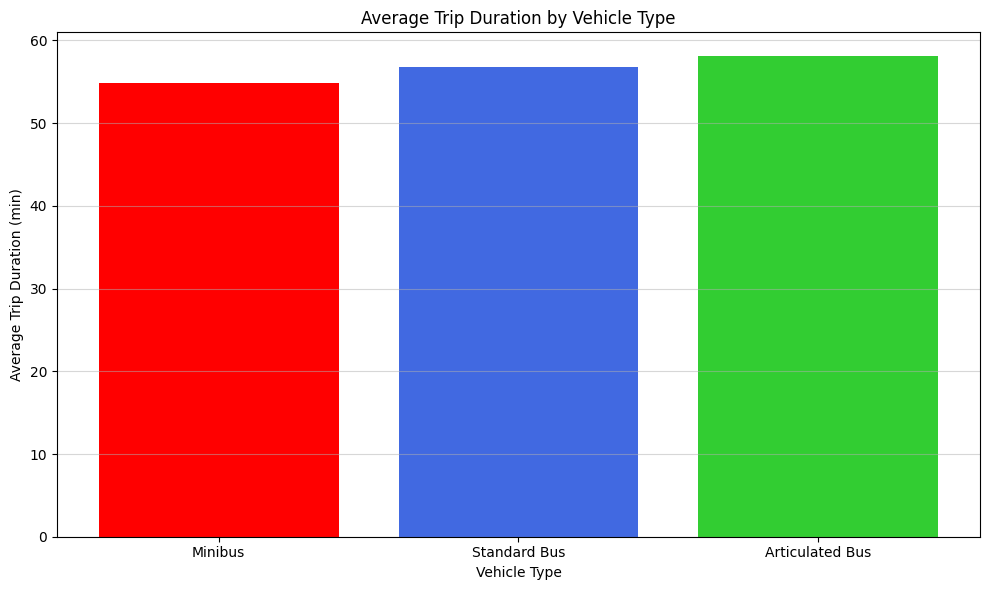

In [113]:
vehicle_utilization = df.groupby("vehicle_type")["trip_duration_min"].mean().reindex(
    ["Minibus", "Standard Bus", "Articulated Bus"]
)

plt.figure(figsize=(10, 6))
plt.bar(
    vehicle_utilization.index,
    vehicle_utilization.values,
    color=["red", "royalblue", "limegreen"]
)
plt.title("Average Trip Duration by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Trip Duration (min)")
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.savefig("expected_output/vehicle_utilization.png")
plt.show()

## Average Boardings by Weather Condition

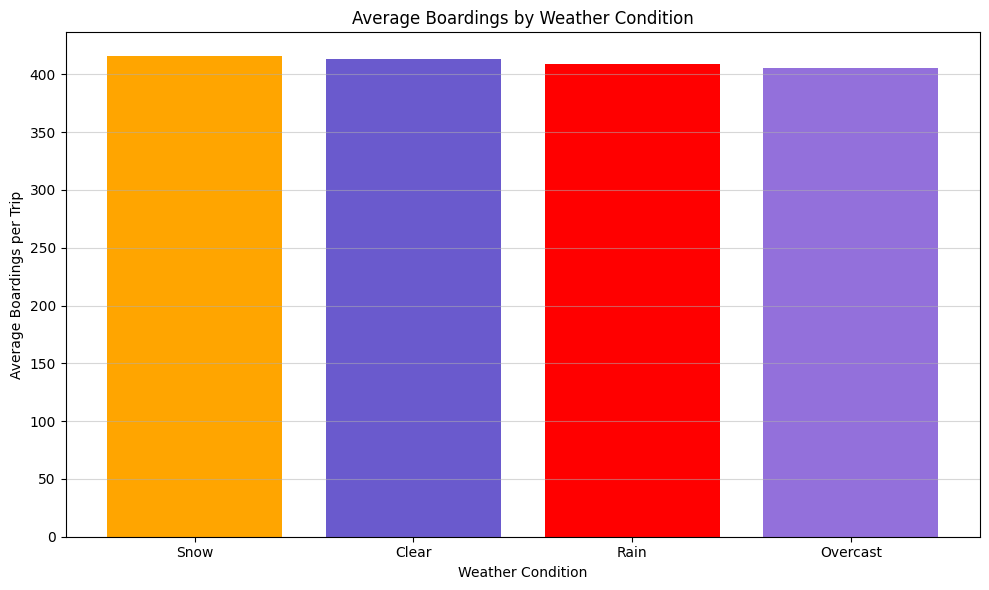

In [114]:
weather_impact = df.groupby("weather")["boarding_count"].mean().reindex(
    ["Snow", "Clear", "Rain", "Overcast"]
)

plt.figure(figsize=(10, 6))
plt.bar(
    weather_impact.index,
    weather_impact.values,
    color=["orange", "slateblue", "red", "mediumpurple"]
)
plt.title("Average Boardings by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Boardings per Trip")
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.savefig("expected_output/weather_impact.png")
plt.show()